# 📊 Sales Summary from SQLite in Google Colab
This notebook loads a small furniture sales dataset into a SQLite database, performs a sales summary query, and visualizes the result with a bar chart.

<h2>Upload the SQL data file</h2>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving furniturestore_sql.txt to furniturestore_sql.txt


<h2>Read SQL from the uploaded text file</h2>

In [7]:
import sqlite3
with open("furniturestore_sql.txt", "r") as file:
    sql_script = file.read()

<h2>Create and connect to the SQLite database

In [8]:
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

<h2>Add this at the top of your script</h2>

In [10]:
# Add this at the top of your script (before CREATE TABLE)
cursor.execute("DROP TABLE IF EXISTS sales")
cursor.executescript(sql_script)
conn.commit()


<h2>Run SQL Query to Summarize Sales</h2>

In [11]:
import pandas as pd

query = '''
SELECT
    product,
    COUNT(*) AS total_qty,
    SUM(price) AS revenue
FROM sales
GROUP BY product
'''

In [12]:
df = pd.read_sql_query(query, conn)
print("📊 Sales Summary:")
print(df)

📊 Sales Summary:
  product  total_qty  revenue
0     Bed          9    64800
1   Chair         43    51600
2   Couch          8    30200


<h2>Plot bar chart</h2>

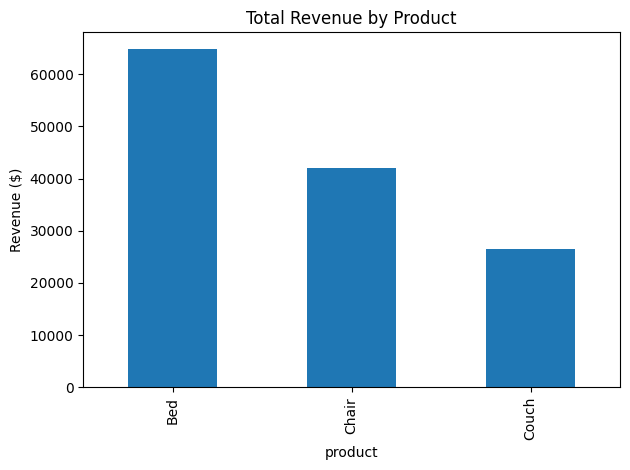

In [25]:
import matplotlib.pyplot as plt

df.plot(kind='bar', x='product', y='revenue', legend=False)
plt.ylabel('Revenue ($)')
plt.title('Total Revenue by Product')
plt.tight_layout()
plt.savefig("Total_Revenue_by_Products.png")
plt.show()

<h2>Filter by Country</h2>

In [15]:
query = '''
SELECT product, COUNT(*) AS qty, SUM(price) AS revenue
FROM sales
WHERE country = 'United States'
GROUP BY product
'''

In [16]:
df = pd.read_sql_query(query, conn)
print("🇺🇸 Sales Summary (United States):")
print(df)

🇺🇸 Sales Summary (United States):
  product  qty  revenue
0     Bed    9    64800
1   Chair   35    42000
2   Couch    7    26600


<h2>Plot bar chart</h2>

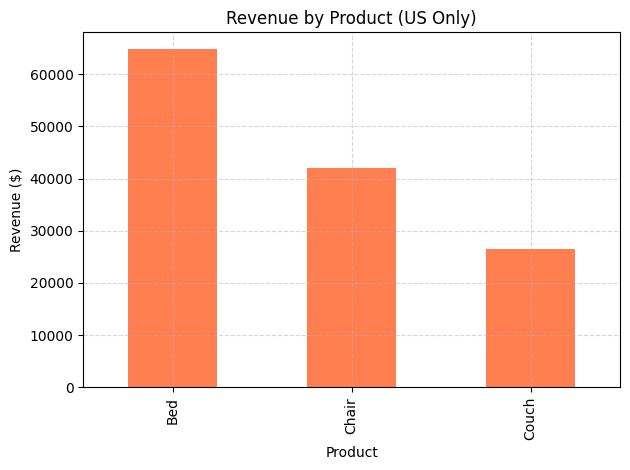

In [24]:

df.plot(kind='bar', x='product', y='revenue', legend=False, color='coral')
plt.title('Revenue by Product (US Only)')
plt.xlabel('Product')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


<h2>Summarized by Day</h2>

In [17]:
query_by_date = '''
SELECT substr(transaction_date, 1, 5) AS date, SUM(price) AS revenue
FROM sales
GROUP BY date
ORDER BY date
'''

In [18]:
df_date = pd.read_sql_query(query_by_date, conn)
print("📅 Revenue by Date:")
print(df_date)

📅 Revenue by Date:
     date  revenue
0   1/1/1    11100
1   1/10/     7200
2   1/11/     1200
3   1/12/     6000
4   1/13/     2400
5   1/14/     1200
6   1/2/1     9600
7   1/3/1    14400
8   1/4/1     9600
9   1/5/1    18000
10  1/6/1    18500
11  1/7/1    12000
12  1/8/1    28200
13  1/9/1     7200


<h2>Plot bar chart</h2>

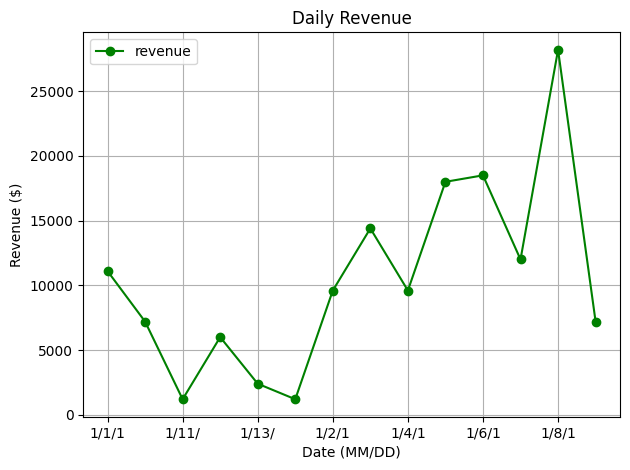

In [19]:
df_date.plot(kind='line', x='date', y='revenue', marker='o', color='green')
plt.title('Daily Revenue')
plt.xlabel('Date (MM/DD)')
plt.ylabel('Revenue ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

<h2>Sales Summary by Supplier</h2>

In [20]:
query_by_supplier = '''
SELECT supplier, COUNT(*) AS sales_count, SUM(price) AS revenue
FROM sales
GROUP BY supplier
'''

In [21]:
df_supplier = pd.read_sql_query(query_by_supplier, conn)
print("🏭 Revenue by Supplier:")
print(df_supplier)

🏭 Revenue by Supplier:
   supplier  sales_count  revenue
0         1           12    25200
1         2           18    38700
2         3           13    30600
3         4           17    52100


<h2>Plot bar chart</h2>

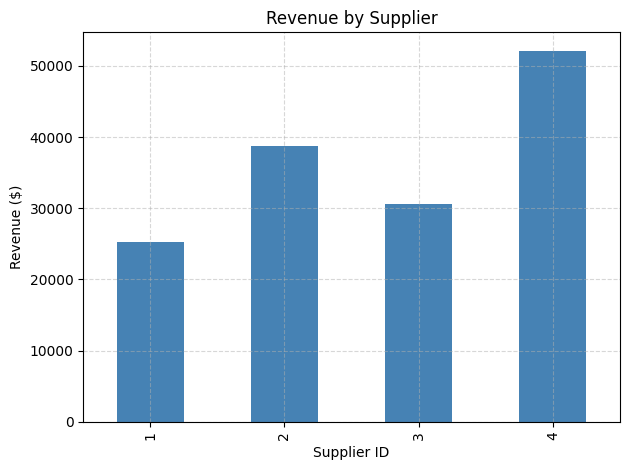

In [22]:
df_supplier.plot(kind='bar', x='supplier', y='revenue', legend=False, color='steelblue')
plt.title('Revenue by Supplier')
plt.xlabel('Supplier ID')
plt.ylabel('Revenue ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()